In [1]:
import numpy as np
import matplotlib . pyplot as plt
from scipy . optimize import minimize
import os
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd
import matplotlib.lines as mlines

from scipy.interpolate import griddata


In [46]:
# Synthetic data
np. random . seed (2025)
n, p = 200 , 2
X = np. random . randn (n, p)
true_w = np. array ([2.0 , -3.0])
logits = X @ true_w
prob = 1 / (1 + np.exp(- logits ))
y = (np. random . rand (n) < prob ). astype ( float )



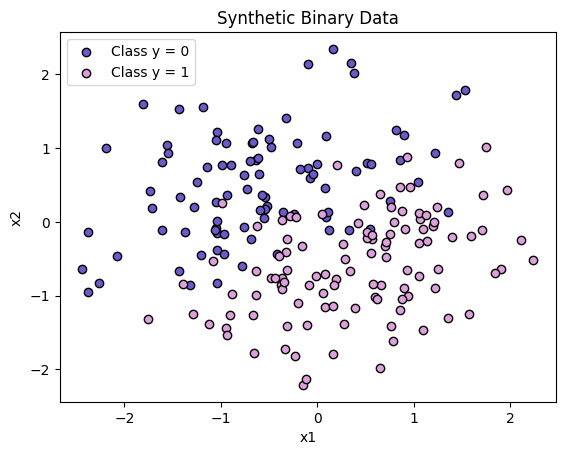

In [50]:
# Plot class 0 (slateblue)
plt.scatter(X[y == 0, 0], X[y == 0, 1],
            c='slateblue', edgecolors='k',
            label='Class y = 0')

# Plot class 1 (plum)
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            c='plum', edgecolors='k',
            label='Class y = 1')

plt.title("Synthetic Binary Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc='upper left')

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "synthetic_data.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

In [25]:
def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def softplus(t):
    out = np.empty_like(t)
    big = t > 0
    out[big] = t[big] + np.log1p(np.exp(-t[big]))
    out[~big] = np.log1p(np.exp(t[~big]))
    return out

def f(w, X, y):
    z = X @ w
    return np.mean(softplus(z) - y * z)

def grad(w, X, y,):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

def hess(w, X, y):
    z = X @ w
    S = sigmoid(z) * (1.0 - sigmoid(z))
    return (X.T * S) @ X / len(y)



def gradient_descent_logistic(X, y, stepsize=0.2, epsilon=1e-6, max_iters=20000):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'w': []}
    for _ in range(max_iters):
        g = grad(w, X, y)
        w_new = w - stepsize * g
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['w'].append(w.copy())
        if np.linalg.norm(w_new - w) <= epsilon * max(1.0, np.linalg.norm(w)):
            w = w_new
            break
        w = w_new
    history['w'].append(w.copy())
    return w, history


def newton_method(X, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'step': [], 'w': [], 'direction': []}
    
    for _ in range(T):
        g = grad(w, X, y)
        H = hess(w, X, y)
        if reg > 0:
            H = H + reg * np.eye(X.shape[1])
        try:
            s = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            H = H + 1e-6 * np.eye(X.shape[1])
            s = np.linalg.solve(H, -g)

        t = 1.0
        f_curr = f(w, X, y)

        while True:
            w_try = w + t * s
            if f(w_try, X, y) <= f_curr + alpha * t * g.dot(s):
                break
            t *= beta
            if t < 1e-12:
                break

        w = w + t * s
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['step'].append(t)
        history['w'].append(w.copy())
        history['direction'].append(s.copy())

        if np.linalg.norm(g) < tol:
            break

    return w, history



In [26]:
#BFGS using scipy
bfgs_hist = {'obj': [], 'norm_g': []}

def callback_bfgs(w):
    bfgs_hist['obj'].append(f(w, X, y))
    bfgs_hist['norm_g'].append(np.linalg.norm(grad(w, X, y)))

res = minimize(lambda w: f(w, X, y),
               x0=np.zeros(X.shape[1]),
               jac=lambda w: grad(w, X, y),
               method='BFGS',
               callback=callback_bfgs,
               options={'gtol': 1e-8, 'maxiter': 500})

In [27]:
#run all the methods
w_gd, hist_gd = gradient_descent_logistic(X, y)
w_newton, hist_newton = newton_method(X, y)
w_bfgs = res.x


print("True w:", true_w)
print("GD estimate:", w_gd)
print("Newton estimate:", w_newton)
print("BFGS estimate:", w_bfgs)


True w: [ 2. -3.]
GD estimate: [ 2.70899588 -4.20292781]
Newton estimate: [ 2.7104343  -4.20535123]
BFGS estimate: [ 2.71043414 -4.20535091]


GD final w: [ 2.70899588 -4.20292781]
Newton final w: [ 2.7104343  -4.20535123]
BFGS final w: [ 2.7104343  -4.20535123]


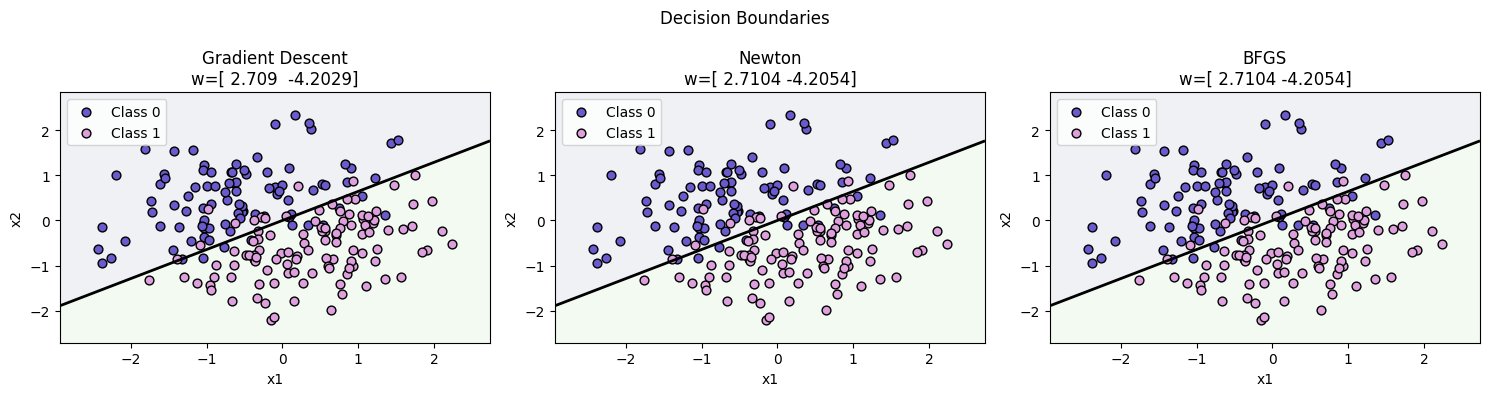

In [ ]:
# ====================================================
# BFGS: uses your f and grad exactly as-is
# ====================================================
bfgs_history = {'w': [], 'obj': [], 'norm_g': []}

def bfgs_callback(wk):
    bfgs_history['w'].append(wk.copy())
    bfgs_history['obj'].append(f(wk, X, y))
    bfgs_history['norm_g'].append(np.linalg.norm(grad(wk, X, y)))

res = minimize(lambda w: f(w, X, y),
               x0=np.zeros(X.shape[1]),
               jac=lambda w: grad(w, X, y),
               method='BFGS',
               callback=bfgs_callback,
               options={'maxiter': 500, 'gtol': 1e-9, 'disp': False})

w_bfgs = res.x
bfgs_history['w'].append(w_bfgs.copy())
bfgs_history['obj'].append(f(w_bfgs, X, y))
bfgs_history['norm_g'].append(np.linalg.norm(grad(w_bfgs, X, y)))


# ====================================================
# Run your optimizers exactly as defined
# ====================================================
w_gd, hist_gd = gradient_descent_logistic(X, y)
w_newton, hist_newton = newton_method(X, y)

print("GD final w:", w_gd)
print("Newton final w:", w_newton)
print("BFGS final w:", w_bfgs)


# ====================================================
# Decision Boundary plotting helper
# ====================================================
def plot_decision_boundary(ax, w, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w).reshape(xx.shape)

    ax.contour(xx, yy, probs, levels=[0.5], linewidths=2, colors='k')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='slateblue', label='y=0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='plum', label='y=1')
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


# ====================================================
# Plot boundaries for each optimizer
# ====================================================


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_decision(axes[0], w_gd, f'Gradient Descent\nw={np.round(w_gd, 4)}')
plot_decision(axes[1], w_newton, f'Newton\nw={np.round(w_newton, 4)}')
plot_decision(axes[2], w_bfgs, f'BFGS\nw={np.round(w_bfgs, 4)}')

plt.suptitle("Decision Boundaries")
plt.tight_layout()
plt.show()



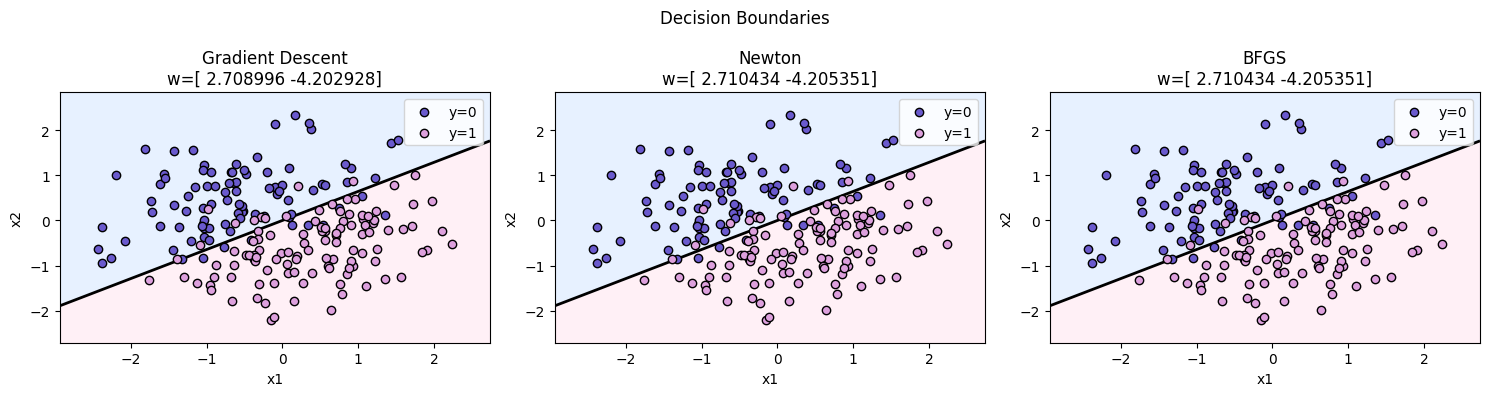

In [51]:
def plot_decision_boundary(ax, w, title, bg_colors=('lightsteelblue', 'mistyrose'), alpha=0.5, resolution=200):
    """
    Plot decision boundary and shade background regions.
    bg_colors: tuple (color_for_class0_region, color_for_class1_region)
    alpha: transparency for the shading
    """
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w).reshape(xx.shape)

    # create a two-level fill: <0.5 and >=0.5
    # levels for contourf: below 0.5 and above 0.5
    cmap_colors = [bg_colors[0], bg_colors[1]]
    # contourf with two regions; extend values slightly to ensure correct bins
    cf = ax.contourf(xx, yy, probs, levels=[0.0, 0.5, 1.0],
                     colors=cmap_colors, alpha=alpha, zorder=0)

    # decision boundary (prob=0.5) on top
    ax.contour(xx, yy, probs, levels=[0.5], linewidths=2, colors='k', zorder=2)

    # data points on top of background
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='slateblue', label='y=0', edgecolors='k', zorder=3)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='plum', label='y=1', edgecolors='k', zorder=3)

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

# alias if your code later calls plot_decision(...)
plot_decision = plot_decision_boundary

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_decision(axes[0], w_gd, f'Gradient Descent\nw={np.round(w_gd,6)}',
              bg_colors=('#D7E9FF', '#FFE6F0'), alpha=0.6)
plot_decision(axes[1], w_newton, f'Newton\nw={np.round(w_newton,6)}',
              bg_colors=('#D7E9FF', '#FFE6F0'), alpha=0.6)
plot_decision(axes[2], w_bfgs, f'BFGS\nw={np.round(w_bfgs,6)}',
              bg_colors=('#D7E9FF', '#FFE6F0'), alpha=0.6)

plt.suptitle("Decision Boundaries")
plt.tight_layout()

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "decision_boundary.png")
plt.savefig(downloads_path, dpi=1200)


plt.show()


/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_15946/2198582777.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs_gd, levels=[0.5], colors='red', linewidths=2, label="GD")
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_15946/2198582777.py:24: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs_new, levels=[0.5], colors='green', linewidths=2, label="Newton")
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_15946/2198582777.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs_bfgs, levels=[0.5], colors='blue', linewidths=2, label="BFGS")


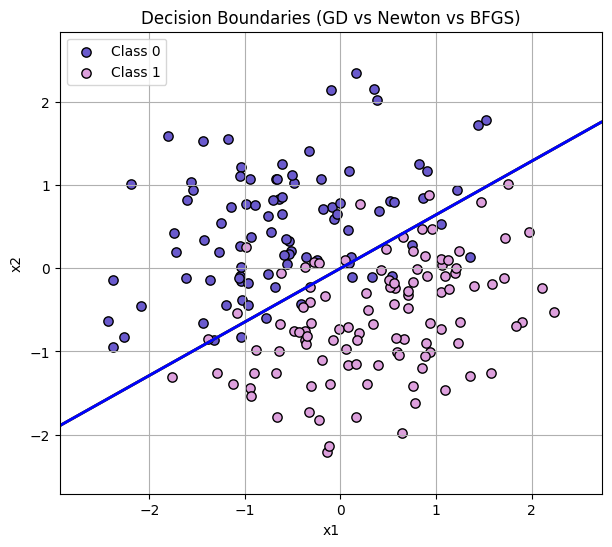

In [23]:
# -------------------------
# Decision boundaries on ONE plot
# -------------------------
plt.figure(figsize=(7, 6))

# Plot data points
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='slateblue', s=45, edgecolor='k', label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='plum', s=45, edgecolor='k', label="Class 1")

# Grid for boundary curves
margin = 0.5
x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.column_stack([xx.ravel(), yy.ravel()])

# Plot decision boundaries
probs_gd = sigmoid(grid @ w_gd).reshape(xx.shape)
probs_new = sigmoid(grid @ w_newton).reshape(xx.shape)
probs_bfgs = sigmoid(grid @ w_bfgs).reshape(xx.shape)

plt.contour(xx, yy, probs_gd, levels=[0.5], colors='red', linewidths=2, label="GD")
plt.contour(xx, yy, probs_new, levels=[0.5], colors='green', linewidths=2, label="Newton")
plt.contour(xx, yy, probs_bfgs, levels=[0.5], colors='blue', linewidths=2, label="BFGS")

# Formatting
plt.title("Decision Boundaries (GD vs Newton vs BFGS)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="upper left")
plt.grid(True)

# Save if desired
path_db = os.path.join(os.path.expanduser("~"), "Downloads", "decision_boundary_overlap.png")
plt.savefig(path_db, dpi=300)
plt.show()

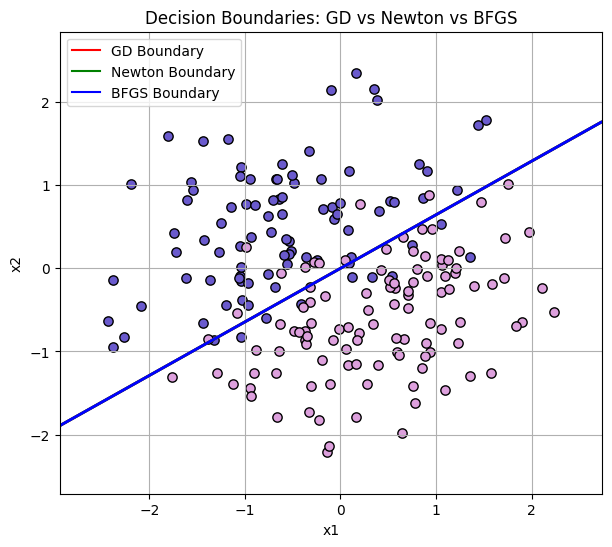

In [28]:

plt.figure(figsize=(7, 6))

# Scatter plot of data
class0 = plt.scatter(X[y == 0, 0], X[y == 0, 1], c='slateblue', s=45, edgecolor='k')
class1 = plt.scatter(X[y == 1, 0], X[y == 1, 1], c='plum', s=45, edgecolor='k')

# Grid
margin = 0.5
x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.column_stack([xx.ravel(), yy.ravel()])

# Decision boundaries
probs_gd = sigmoid(grid @ w_gd).reshape(xx.shape)
probs_new = sigmoid(grid @ w_newton).reshape(xx.shape)
probs_bfgs = sigmoid(grid @ w_bfgs).reshape(xx.shape)

c_gd = plt.contour(xx, yy, probs_gd, levels=[0.5], colors='red', linewidths=2)
c_new = plt.contour(xx, yy, probs_new, levels=[0.5], colors='green', linewidths=2)
c_bfgs = plt.contour(xx, yy, probs_bfgs, levels=[0.5], colors='blue', linewidths=2)

# Proxy artists for legend
gd_line = mlines.Line2D([], [], color='red', label='GD Boundary')
new_line = mlines.Line2D([], [], color='green', label='Newton Boundary')
bfgs_line = mlines.Line2D([], [], color='blue', label='BFGS Boundary')

# Add legends
plt.legend(
    handles=[gd_line, new_line, bfgs_line],
    loc='upper left'
)

plt.title("Decision Boundaries: GD vs Newton vs BFGS")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)

# Save if needed
path_db = os.path.join(os.path.expanduser("~"), "Downloads", "decision_boundaries_labeled.png")
plt.savefig(path_db, dpi=300)

plt.show()

Saved objective plot to: /Users/sk/Downloads/objective_vs_iteration.png


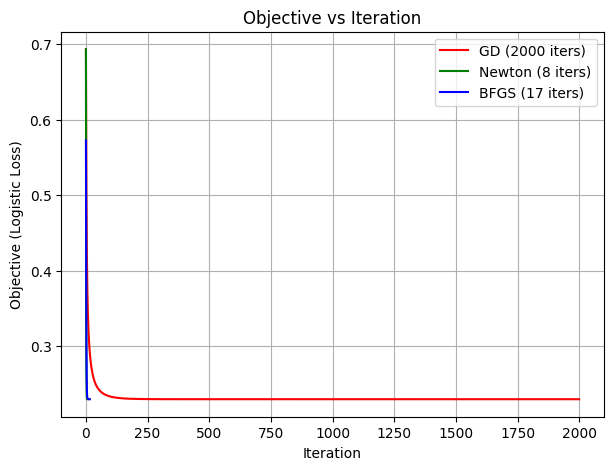

In [38]:
plt.figure(figsize=(7, 5))
plt.plot(obj_gd, label=f'GD ({len(obj_gd)} iters)', color='red')
plt.plot(obj_new, label=f'Newton ({len(obj_new)} iters)', color='green')
plt.plot(obj_bfgs, label=f'BFGS ({len(obj_bfgs)} iters)', color='blue')
plt.xlabel("Iteration")
plt.ylabel("Objective (Logistic Loss)")
plt.title("Objective vs Iteration")
plt.legend()
plt.grid(True)

path_obj = os.path.join(os.path.expanduser("~"), "Downloads", "objective_vs_iteration.png")
plt.savefig(path_obj, dpi=300)
print(f"Saved objective plot to: {path_obj}")
plt.show()

Saved gradient-norm plot to: /Users/sk/Downloads/gradnorm_vs_iteration.png


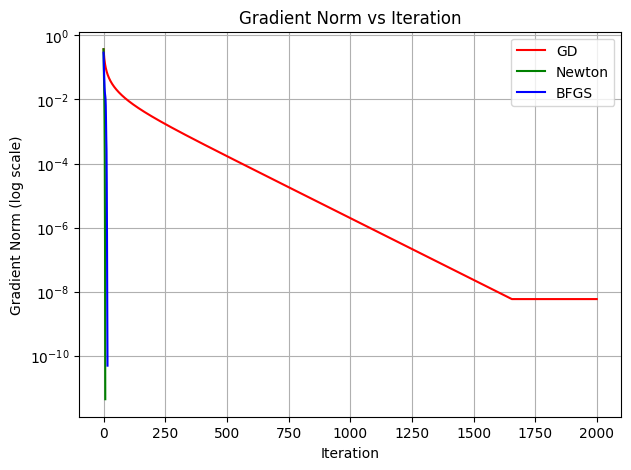

In [39]:
plt.figure(figsize=(7, 5))
plt.semilogy(gn_gd, label='GD', color='red')
plt.semilogy(gn_new, label='Newton', color='green')
plt.semilogy(gn_bfgs, label='BFGS', color='blue')
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm (log scale)")
plt.title("Gradient Norm vs Iteration")
plt.grid(True)
plt.legend()

path_grad = os.path.join(os.path.expanduser("~"), "Downloads", "gradnorm_vs_iteration.png")
plt.savefig(path_grad, dpi=300)
print(f"Saved gradient-norm plot to: {path_grad}")
plt.show()

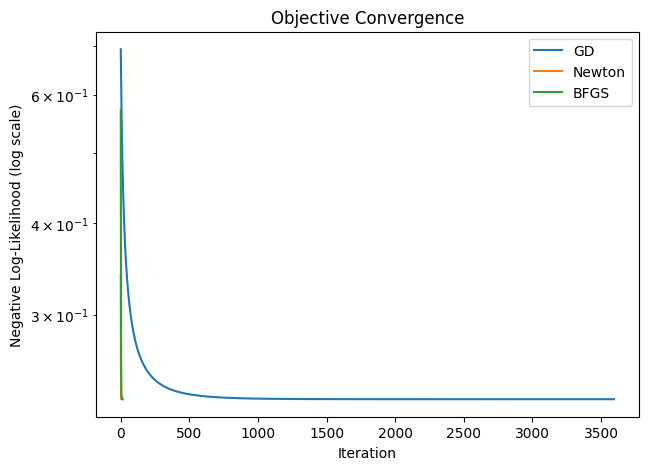

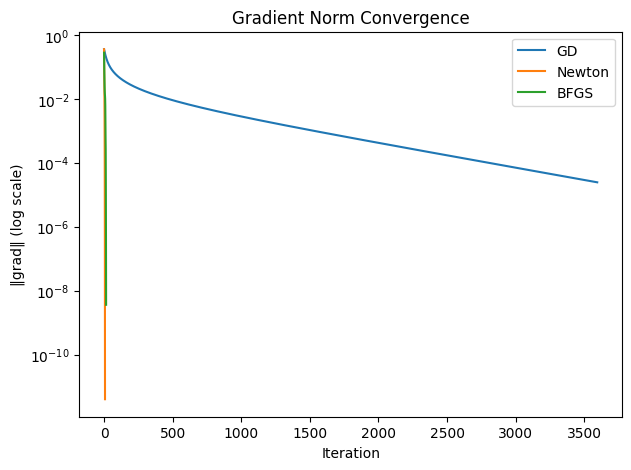

In [43]:
plt.figure(figsize=(7,5))
plt.yscale("log")
plt.plot(hist_gd['obj'], label='GD')
plt.plot(hist_newton['obj'], label='Newton')
plt.plot(bfgs_hist['obj'], label='BFGS')
plt.title("Objective Convergence")
plt.xlabel("Iteration")
plt.ylabel("Negative Log-Likelihood (log scale)")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.yscale("log")
plt.plot(hist_gd['norm_g'], label='GD')
plt.plot(hist_newton['norm_g'], label='Newton')
plt.plot(bfgs_hist['norm_g'], label='BFGS')
plt.title("Gradient Norm Convergence")
plt.xlabel("Iteration")
plt.ylabel("‖grad‖ (log scale)")
plt.legend()
plt.show()

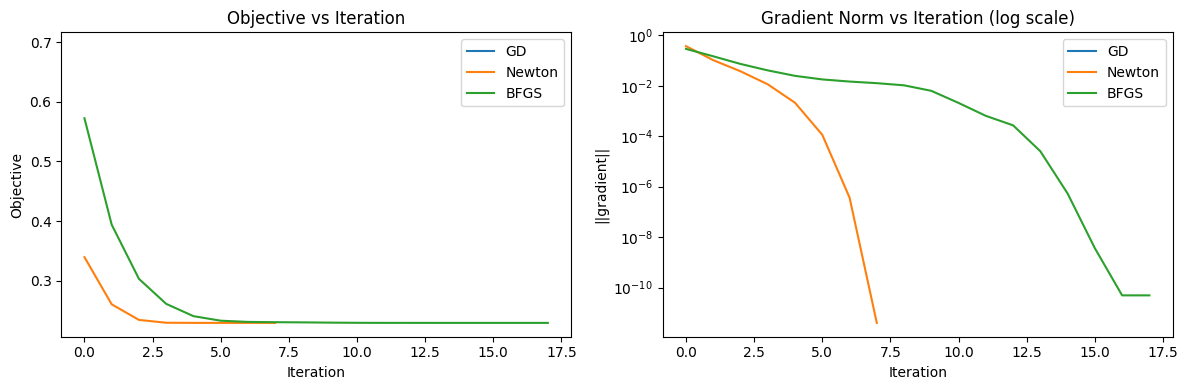

In [14]:
# ====================================================
# Convergence plots
# ====================================================
plt.figure(figsize=(12, 4))

# Objective history
plt.subplot(1, 2, 1)
plt.plot(hist_gd['obj'], label='GD')
plt.plot(hist_newton['obj'], label='Newton')
plt.plot(bfgs_history['obj'], label='BFGS')
plt.title("Objective vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.legend()

# Gradient norms
plt.subplot(1, 2, 2)
plt.semilogy(hist_gd['norm_g'], label='GD')
plt.semilogy(hist_newton['norm_g'], label='Newton')
plt.semilogy(bfgs_history['norm_g'], label='BFGS')
plt.title("Gradient Norm vs Iteration (log scale)")
plt.xlabel("Iteration")
plt.ylabel("||gradient||")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
def gradient_descent_logistic(X, y, stepsize=0.2, epsilon=1e-6, max_iters=20000):
    """
    Fixed gradient descent that:
      - does the update repeatedly (no early return inside the loop),
      - records objective, gradient norm, and w at each iteration,
      - stops on relative change in w.
    """
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'w': []}

    for _ in range(max_iters):
        g = grad(w, X, y)

        # record current state BEFORE the update
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['w'].append(w.copy())

        # gradient step
        w_new = w - stepsize * g

        # stopping criterion (relative change)
        if np.linalg.norm(w_new - w) <= epsilon * max(1.0, np.linalg.norm(w)):
            w = w_new
            # record final state after the last step
            history['obj'].append(f(w, X, y))
            history['norm_g'].append(np.linalg.norm(grad(w, X, y)))
            history['w'].append(w.copy())
            break

        w = w_new

    else:
        # loop finished without break: record final state
        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(grad(w, X, y)))
        history['w'].append(w.copy())

    return w, history